In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License


## Time taken to execute a general single or multi-qubit gate

In [1]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

### Get a general n-qubit unitary

In [2]:
from scipy.stats import unitary_group
from qiskit.circuit.library import UnitaryGate

n_qubits = 1
mat = unitary_group.rvs(2**n_qubits, random_state = 0)
gate = UnitaryGate(mat, 'general_unitary')
print(gate)

# Transpile general n-qubit gate to native gates
qc_t = qiskit.QuantumCircuit(1)
qc_t.append(gate, [0])
unitary_circ = qiskit.transpile(qc_t, basis_gates=['sx', 'cx', 'rz', 'id'])
print(unitary_circ)

Instruction(name='unitary', num_qubits=1, num_clbits=0, params=[array([[ 0.60648474+0.64207019j, -0.45716188-0.1045234j ],
       [ 0.33649209+0.32664231j,  0.86872421+0.15936159j]])])
global phase: 5.21
   ┌──────────────┐┌────┐┌─────────────┐┌────┐┌────────────┐
q: ┤ Rz(-0.58912) ├┤ √X ├┤ Rz(-2.1654) ├┤ √X ├┤ Rz(3.0982) ├
   └──────────────┘└────┘└─────────────┘└────┘└────────────┘


In [12]:
device_name = "noisy_sim_with_shots"
submitter = CircuitSubmitter("time_taken_to_execute_a_general_single_or_multi_qubit_gateno", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.noisy_sim.set_options(noise_model=noise_model)

In [4]:
circuits = []
total_repetitions = 1000
repetitions = [i for i in range(1, total_repetitions, total_repetitions // 10)]
for repetition in repetitions:
    circuit = qiskit.QuantumCircuit(QuantumRegister(2))
    circuit.sx(0)
    circuit.sx(0)
    for _ in range(repetition):
        for gate,qargs,cargs in unitary_circ.data:
            circuit.append(gate, [i.index + 1 for i in qargs])
            if isinstance(gate, qiskit.circuit.library.standard_gates.rz.RZGate):
                # Here we treat RZ as a virtual gate and 
                # so do not want to increase time step when RZ is applied
                pass
            else:
                circuit.id(0)
                circuit.barrier()
    circuit.measure_all()
    circuits.append(circuit)


/tmp/ipykernel_280236/2781907011.py:10: DeprecationWarning: The property ``qiskit.circuit.bit.Bit.index`` is deprecated as of qiskit-terra 0.17. It will be removed no earlier than 3 months after the release date. Instead, use :meth:`~qiskit.circuit.quantumcircuit.QuantumCircuit.find_bit` to find all the containing registers within a circuit and the index of the bit within the circuit.
  circuit.append(gate, [i.index + 1 for i in qargs])


In [5]:
shots = 1024
tasks = submitter.submit_circuits(
    shots=shots,
    qasm_strs=[c.qasm() for c in circuits],
    skip_asking=True,
    skip_transpilation=True,
)

Ready to run 10 circuits on noisy_sim_with_shots with 1024 shots.
Cost: 10 * ($0 + 1024 * $0) = $0.00.
Circuits have been submitted


In [6]:
all_counts = submitter.retrieve_counts([task.id for task in tasks], wait=True)

2024-07-26 16:20:04 All circuits are finished


In [8]:
counts = []
for counts_this_circuit in all_counts:
    for key in ['00', '01', '10', '11']:
        if key not in counts_this_circuit.keys():
            counts_this_circuit[key] = 0
    counts.append(counts_this_circuit['10'] + counts_this_circuit['11'])

[0.97167969 0.79296875 0.65820312 0.52539062 0.453125   0.36914062
 0.28613281 0.24121094 0.20214844 0.18554688]


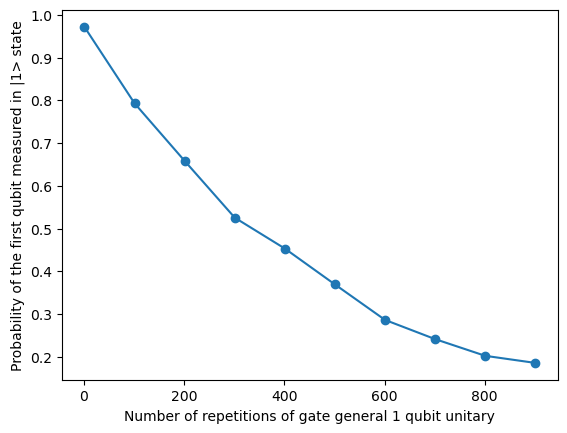

In [9]:
# Convert counts into probabilities and plot curve
probabilities = np.array(counts) / shots
print(probabilities)
plt.plot(repetitions, probabilities, "-o")
plt.xlabel(f"Number of repetitions of gate general {n_qubits} qubit unitary")
plt.ylabel("Probability of the first qubit measured in |1> state")
plt.savefig(submitter.benchmark_path + "/plot.png")
plt.show()

In [10]:
def exp_func(x, amp, dr):
    return amp * np.exp(x * -1 / dr)

In [11]:
# Assume T1 time is known, either from device documentation or obtained by measurements
T1 = 50

# Fit for decay curve and calculate estimated gate time
popt, pcov = curve_fit(exp_func, repetitions, probabilities, p0=[1, 1000], method='trf')
gate_time = T1 / popt.tolist()[1]
result_str = f"Single qubit gate time is estimated to be {gate_time}, in the same units as the provided T1 time"
with open(submitter.benchmark_path + "/results.txt", "w+") as f:
    f.write(result_str)
print(result_str)

Single qubit gate time is estimated to be 0.09766851262100897, in the same units as the provided T1 time
